### **Exercise 1 (Isosurface Post-Processing in ParaView)**

In this task we will post-process an isosurface mesh using the software ParaView.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

**a) Contour Extraction**

We will try to get the isosurface showed in the exercise sheet using the Contour filter.


After adjusting the needed paramter to modify the density of the material and setting it to $68 \in [0,255]$, the following result is obtained:

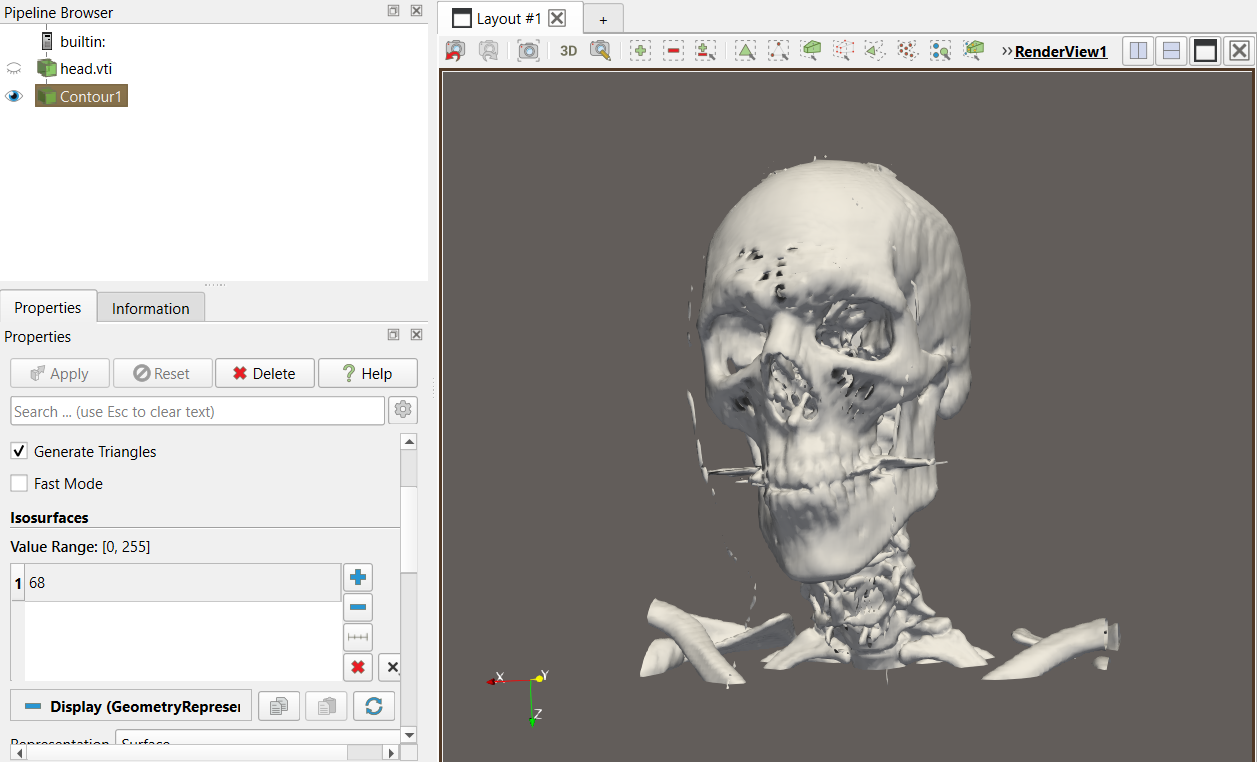

**b) SurfaceNormals Filter and Camera Linking**

We will explore the effect of replacing the given normals for the ones estimated from the triangular mesh itself, by adding a SurfaceNormals filter. To compare these two versions we will link the camera to the existing view.

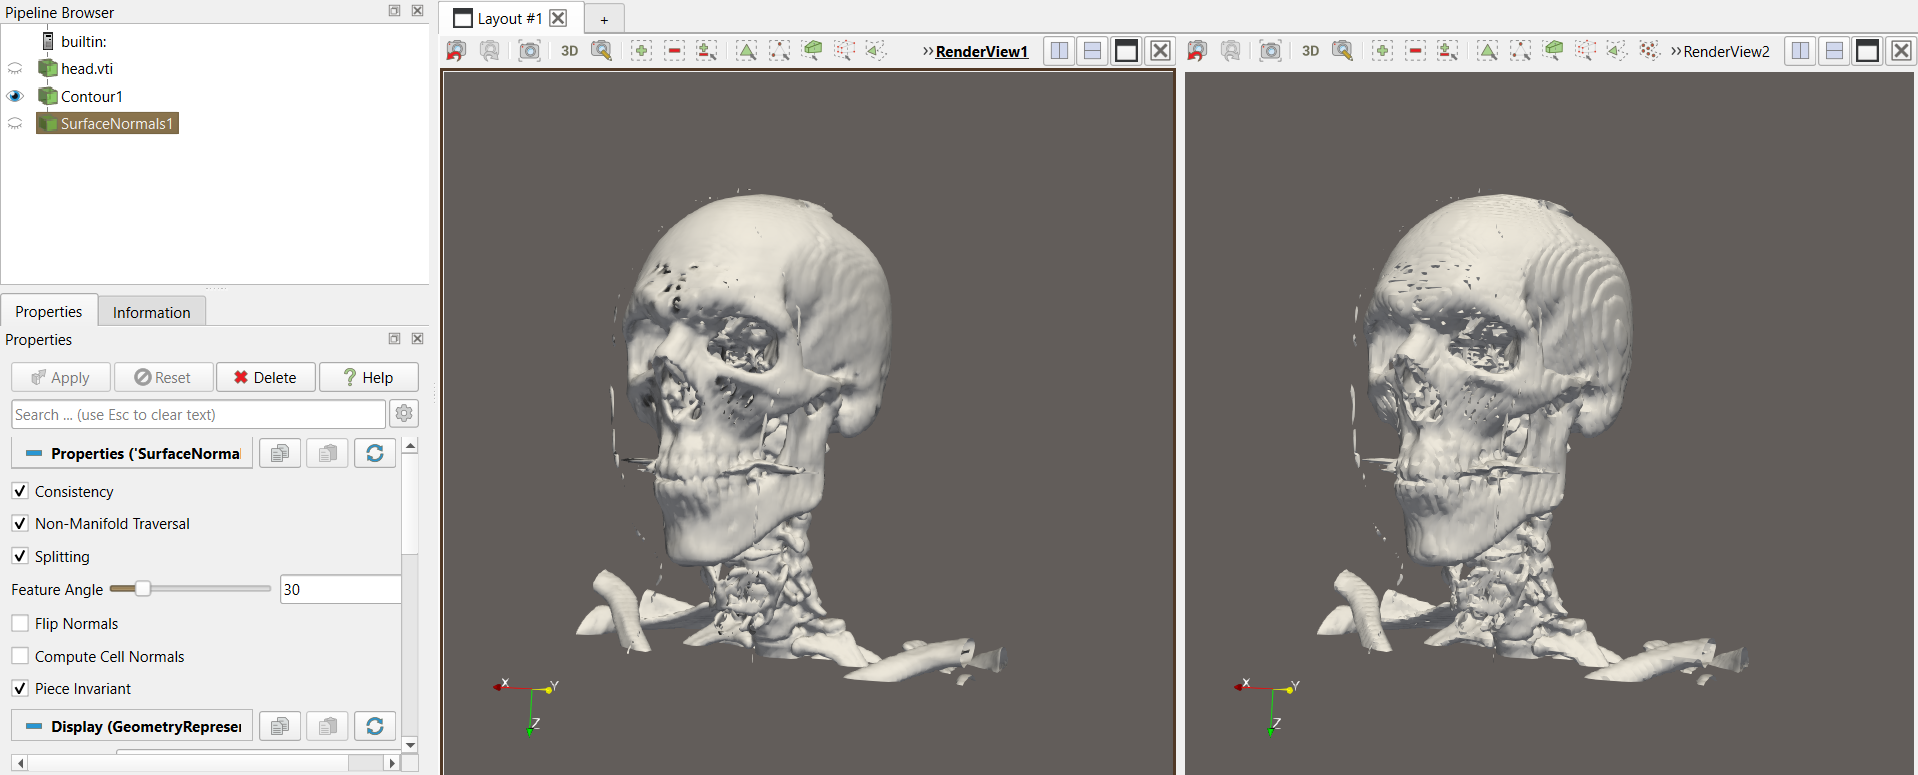
(right is the one with the SurfaceNormals filter)

The default Contour visualization exhibits smooth, continuous lighting gradients across the entire surface of the skull, capturing natural curvature. Once the SurfaceNormals filter is activated, the mesh shifts to a sharper, pixelated appearance where individual flat triangle boundaries and sharp polygon edges become clearly visible to the eye.

Linking the camera was really useful to zoom directly into a specific region, like the cheekbones or the forehead processes, and witness exactly how the lighting changes.

**c) Feature Angle Modification**

By default, the feature angle is set to 30º. Lets change this setting to 180º for the SurfaceNormals filter.

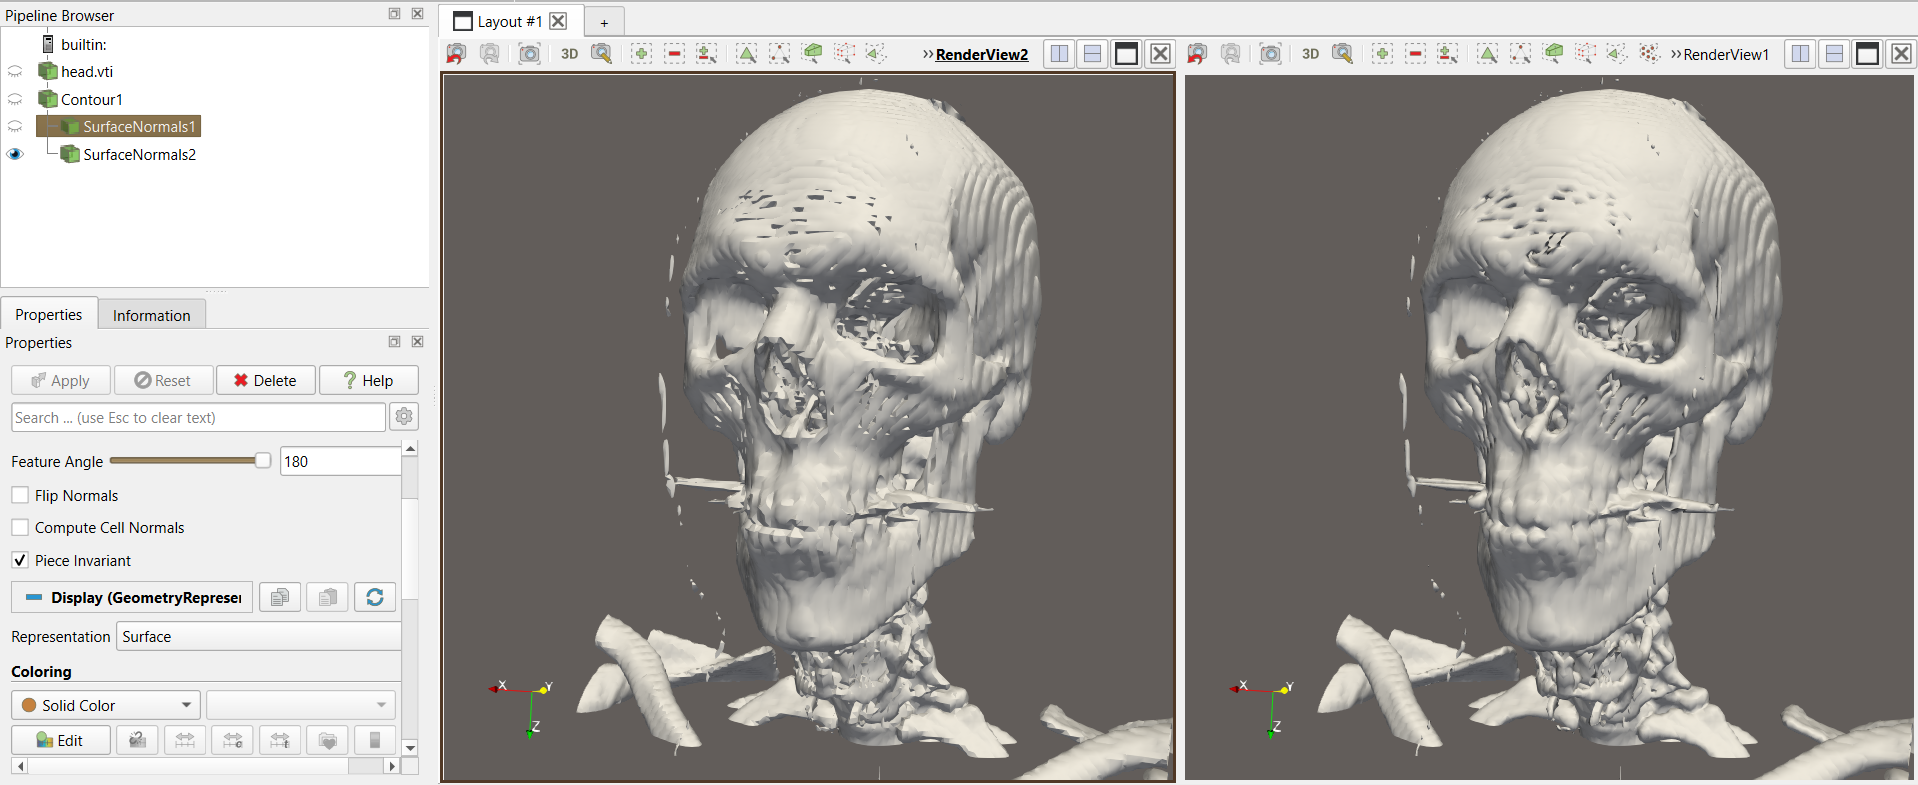
(left is 30º and right is 180º)

The SurfaceNormals filter uses the *Feature Angle* threshold to determine whether an edge between two adjacent triangles represents a sharp, distinct structural boundary that should be preserved. 

Therefore, when the feature angle parameter is increased from the default 30º to the maximum 180º, the sharp boundaries that were prominent in part b) vanish. The skull's surface geometry transitions back to looking smooth, even though the visualization is still pulling normals calculated from the discrete triangle mesh.

This is because by setting the angle to 180º, it is impossible for any two adjacent triangles to exceed the threshold. Consequently, the filter forces normal vector averaging across all shared edges indiscriminately. This blends the lighting continuously over every polygon boundary, completely erasing the sharp facets.

**d) Laplacian Smoothing and Re-normalizing**

Now we will be using the Smooth filter to smooth the outcome of SurfaceNormals filter. 

After applying 100 Laplacian Smoothing Iterations to the SurfaceNormals filter (going back to the default 30º) we get:

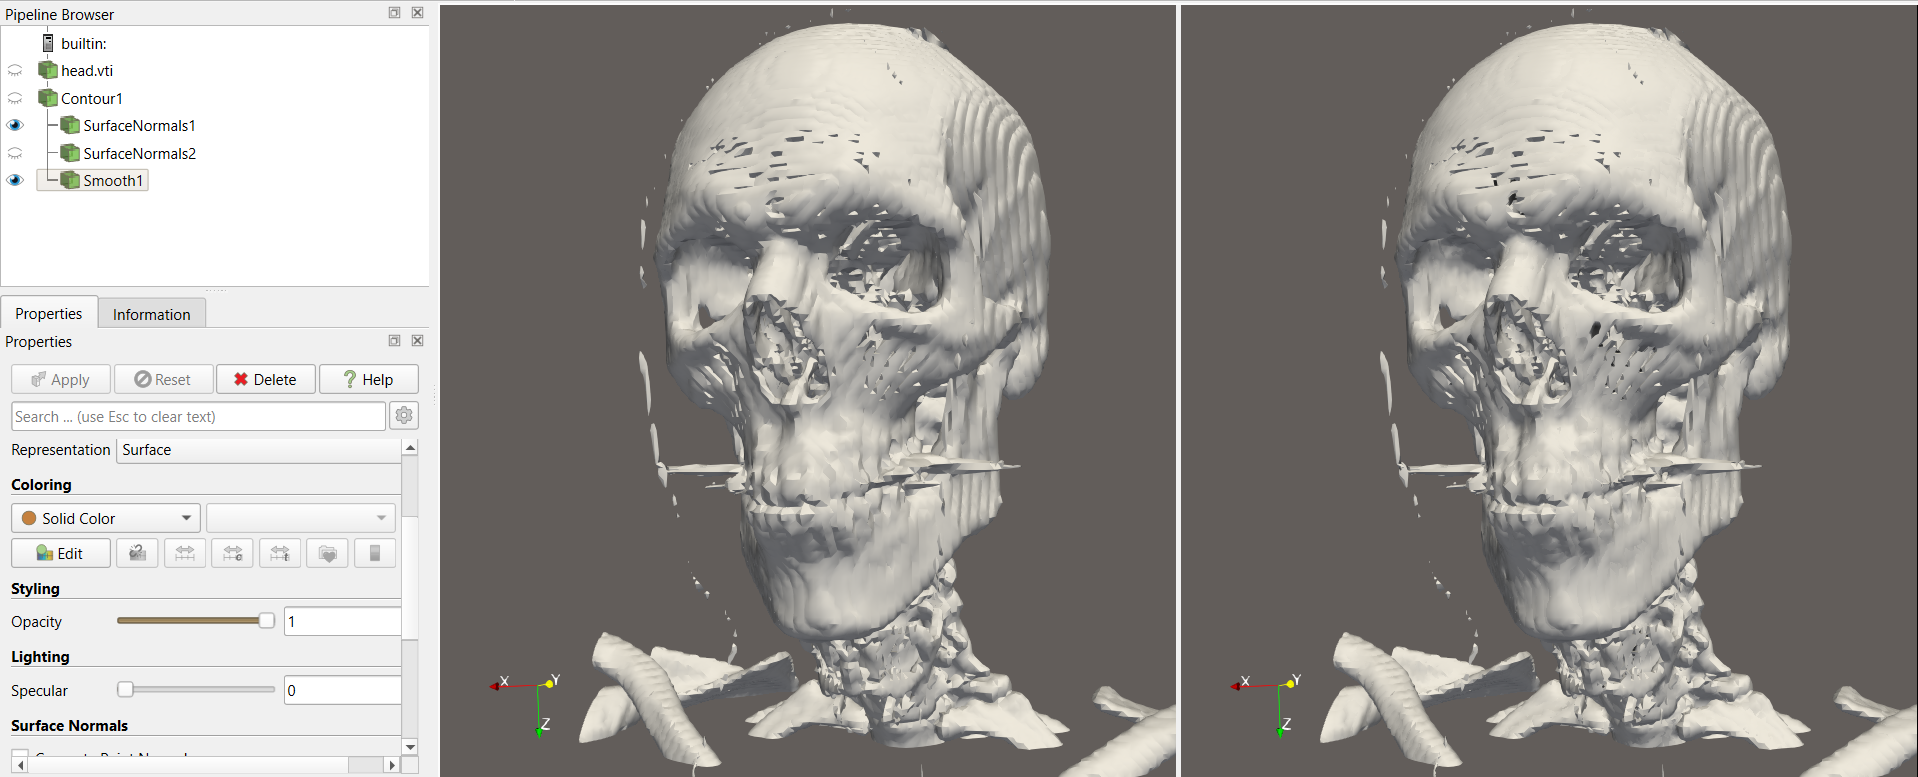
(right is after applying the 100 Laplacian Smoothing filter)

Upon applying 100 iterations of the Laplacian smoothing filter, the macroscopic changes to the skull geometry are subtle. Rather than a dramatic structural collapse or shrinking, the filter primarily acts as a high-frequency low-pass noise filter, shaving off sub-voxel roughness while preserving the anatomical features.

Then we add another SurfaceNormals filter after the smoothing:

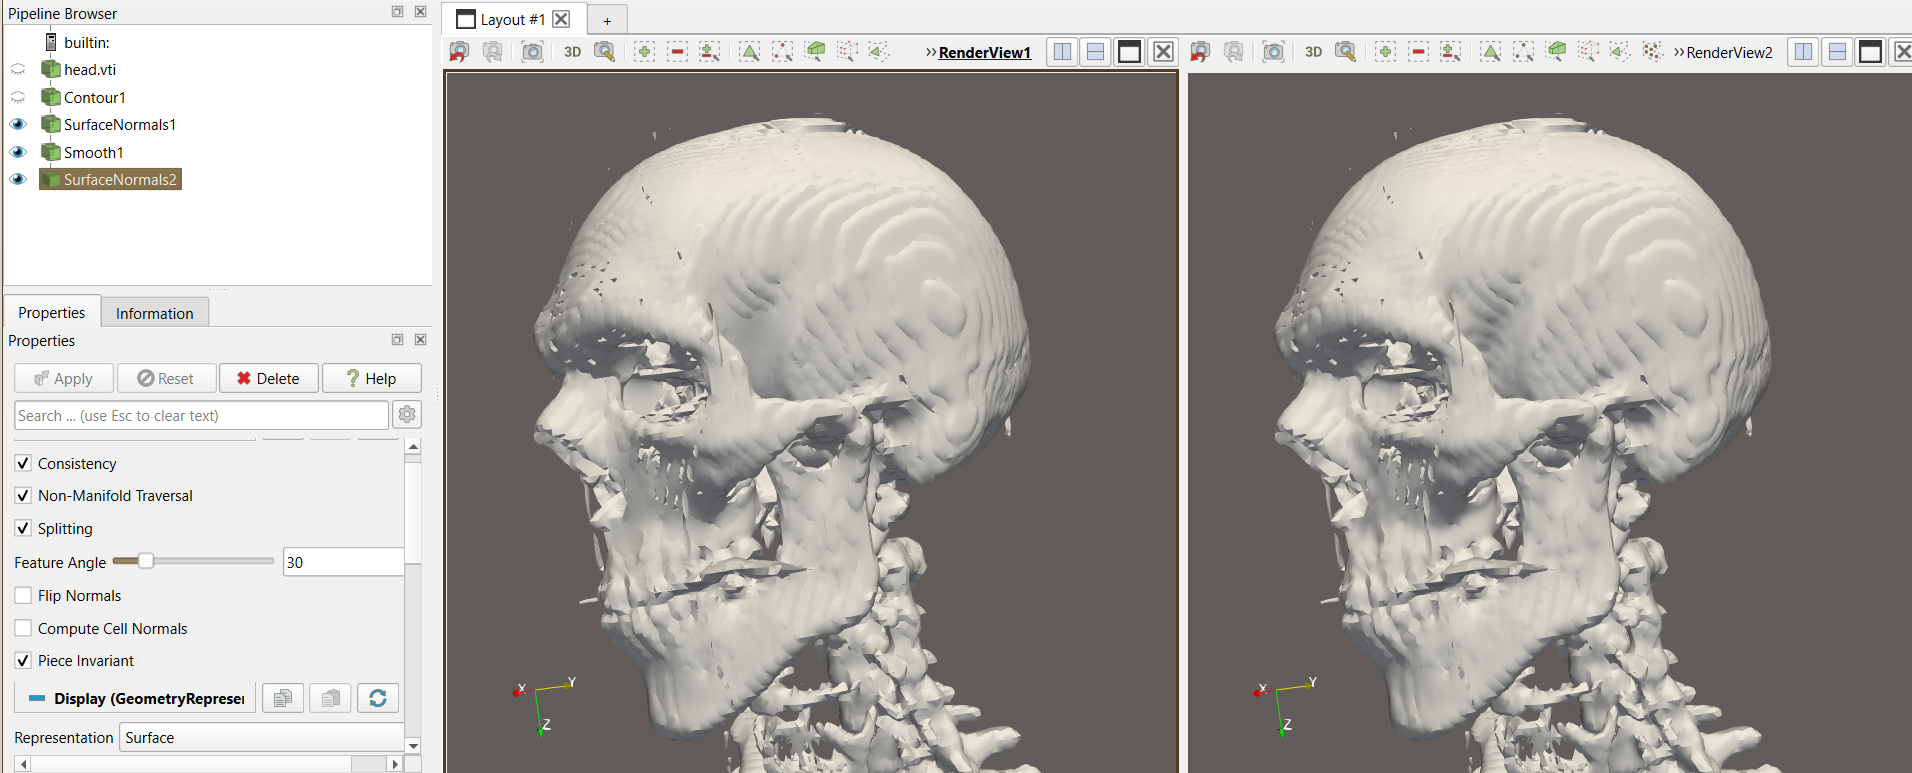
(in the left one we applied again the SurfaceNormals filter)

Re-applying the SurfaceNormals filter forces ParaView to recompute fresh normal vectors based entirely on the updated, softened geometry, ensuring physically accurate light reflection.

**e) Mesh Decimation Analysis**

Now we will add a Decimate filter to reduce the number of triangles in the original mesh. Decimation is used to reduce the complexity of the mesh by merging adjacent triangles together, which makes data storage and rendering much more efficient.

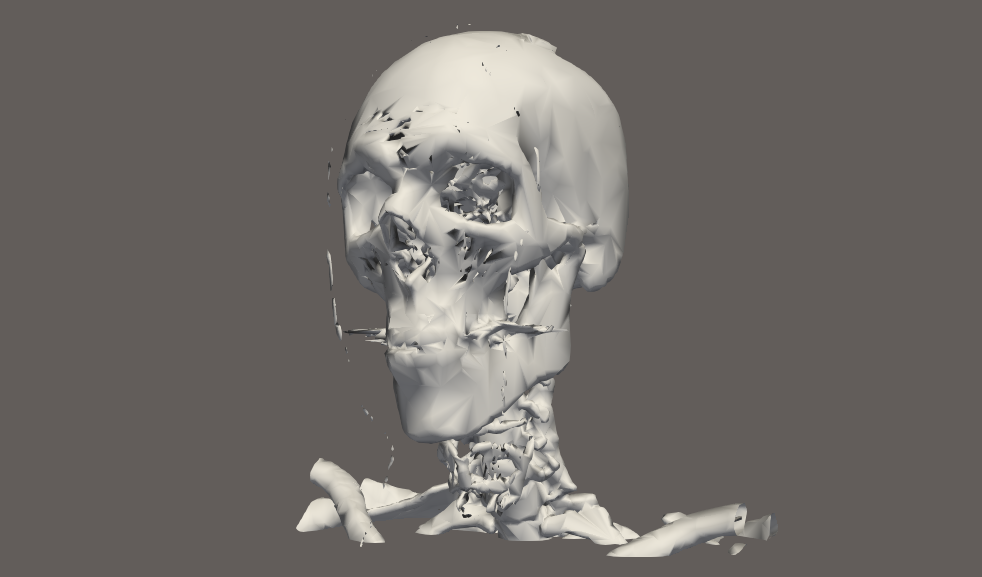
(reduction factor set to 0.85)

We can see that in flat areas (like the forehead or sides of the skull), tiny dense triangles will group into much larger triangles. However, the more complex structural areas (like around the teeth or nose) will also suffer this smoothness and not every detail is preserved. Nevertheless, important anatomical landmarkes, even the teeth, are still preserved with this reduction factor and no visual glitches occured yet.

If we increase the reduction factor to 0.92, the teeth are to preserved anymore. We can still know that there is the mouth but the relief of the teeth or the distinction between different teeth is not appreciated anymore.

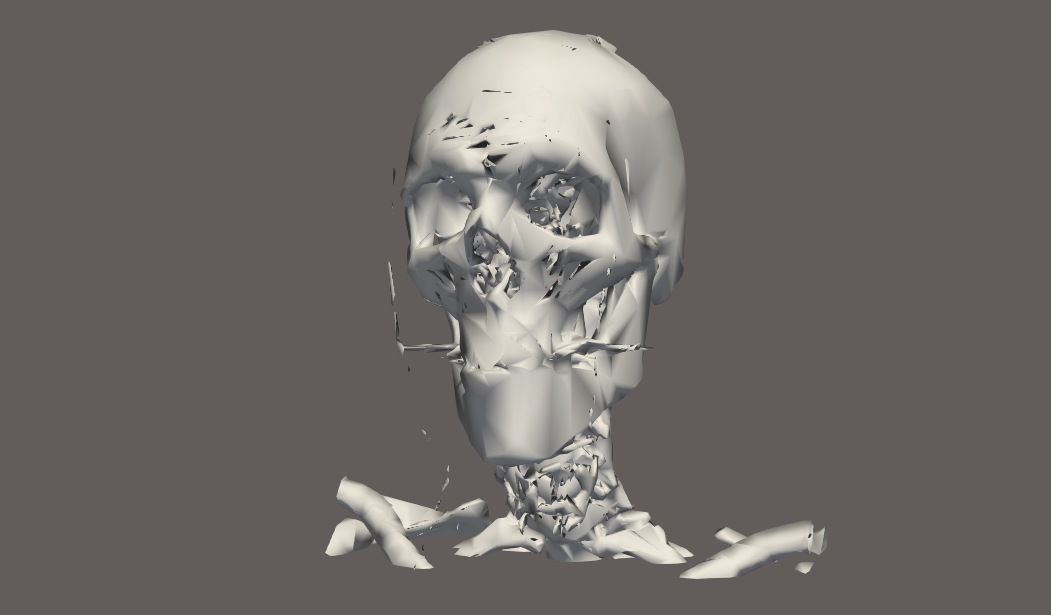

Moreover, visual glitching is appreciated around the eyes and nose, creating some unreal cracks or fissures.
